# Evaluate different thresholds (TH20, TH50, TH100, TH500, TH10_500)

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.getcwd()
os.chdir('..')

CPU times: user 2.48 s, sys: 290 ms, total: 2.77 s
Wall time: 54.5 s


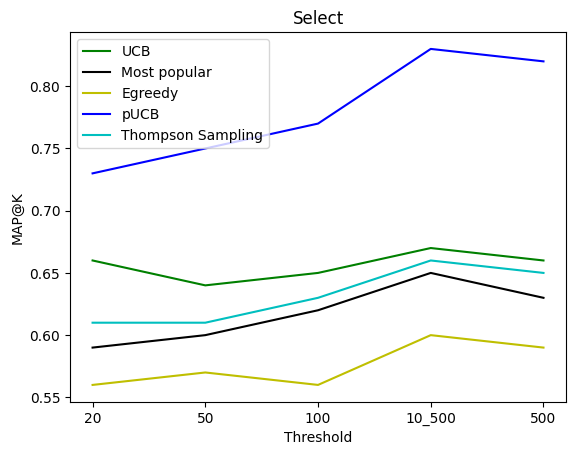

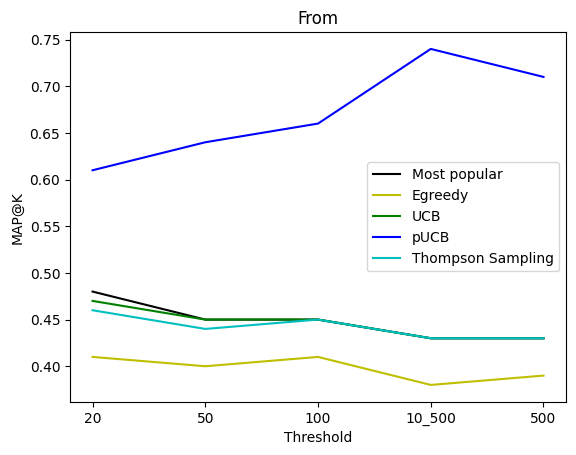

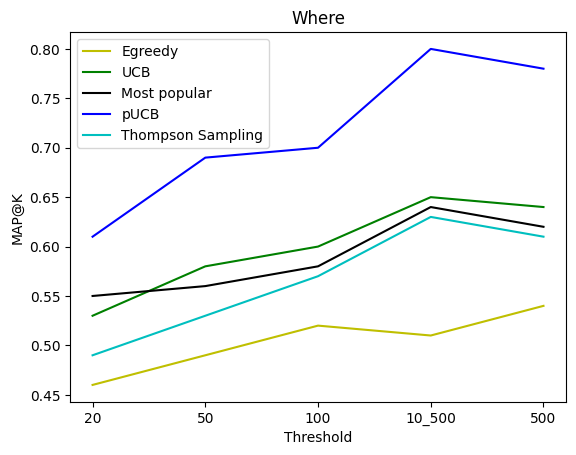

In [2]:
%%time
from sqlcompletions.evaluator import run_plot_parameter, create_tests
from sqlcompletions.sqlparser import schema



clauses_to_test = [0, 1, 2]
k_to_test = [[5],[3],[3]]
thresholds_to_test = {0: "20", 1:"50", 2: "100", 3: "10_500", 4:"500"}


db = schema()
results = []
for clause in clauses_to_test:
    tests = []
    for k in k_to_test[clause]:
        for th_key in thresholds_to_test:
            th = thresholds_to_test[th_key]
            add_tests = create_tests(algorithms= ["egreedy","thompson", "ucb", "pucb",'popular'], clause=clause, top_k = k , db = db , th =th)
            for test in add_tests: # add common
                test.update({
                    'parameter_value': th_key
                })
        
            tests += add_tests  
    results.append(run_plot_parameter(tests, parameter_name = "Threshold", param_map = thresholds_to_test).results)

## SELECT

In [3]:
results[0]

,Algorithm,20,50,100,10_500,500
0,UCB,0.66,0.64,0.65,0.67,0.66
1,Most popular,0.59,0.60,0.62,0.65,0.63
2,Egreedy,0.56,0.57,0.56,0.60,0.59
3,pUCB,0.73,0.75,0.77,0.83,0.82
4,Thompson Sampling,0.61,0.61,0.63,0.66,0.65


## FROM

In [4]:
results[1]

,Algorithm,20,50,100,10_500,500
0,Most popular,0.48,0.45,0.45,0.43,0.43
1,Egreedy,0.41,0.40,0.41,0.38,0.39
2,UCB,0.47,0.45,0.45,0.43,0.43
3,pUCB,0.61,0.64,0.66,0.74,0.71
4,Thompson Sampling,0.46,0.44,0.45,0.43,0.43


## WHERE

In [5]:
results[2]

,Algorithm,20,50,100,10_500,500
0,Egreedy,0.46,0.49,0.52,0.51,0.54
1,UCB,0.53,0.58,0.60,0.65,0.64
2,Most popular,0.55,0.56,0.58,0.64,0.62
3,pUCB,0.61,0.69,0.70,0.80,0.78
4,Thompson Sampling,0.49,0.53,0.57,0.63,0.61
